# Stress Classification from ECG HRV Features
**Dataset:** WESAD  
**Labels:** 1 = Baseline, 2 = Stress, 3 = Amusement  
**Task:** Binary classification — Stress (2) vs. Non-stress (1 + 3)  
**Validation:** Leave-One-Subject-Out (LOSO) cross-validation  
**Models:** SVM, Random Forest, LDA, KNN, Gradient Boosting

## 1. Imports

In [19]:
import numpy as np
import pandas as pd
import neurokit2 as nk
import pickle
import os
import warnings

from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score,
    recall_score, confusion_matrix, classification_report
)
from sklearn.pipeline import Pipeline as SklearnPipeline

from IPython.display import display
import matplotlib.pyplot as plt
import seaborn as sns

from pipeline import Pipeline

## 2. Feature Extraction

For each 30-second ECG chunk we extract 8 HRV features:

| Feature | Description |
|---------|-------------|
| `mean_rr` | Mean RR interval (ms) |
| `mean_hr` | Mean heart rate (bpm) |
| `sdnn` | Std of RR intervals |
| `rmssd` | Root mean square of successive RR differences |
| `pnn50` | % of successive RR differences > 50 ms |
| `lf_power` | Low-frequency HRV power (0.04–0.15 Hz) |
| `hf_power` | High-frequency HRV power (0.15–0.40 Hz) |
| `lf_hf_ratio` | LF/HF ratio (sympathovagal balance) |

In [20]:
def extract_hrv_features(ecg_chunk, fs=700):
    """
    Extract HRV features from a single ECG chunk.
    Returns a dict of features, or None if extraction fails.
    """
    try:
        with warnings.catch_warnings():
            warnings.filterwarnings('ignore')

            # Clean and detect R-peaks
            cleaned = nk.ecg_clean(ecg_chunk, sampling_rate=fs)
            _, peaks = nk.ecg_peaks(cleaned, sampling_rate=fs)
            rpeaks = peaks["ECG_R_Peaks"]

            if len(rpeaks) < 5:
                return None

            # RR intervals in ms
            rr = np.diff(rpeaks) / fs * 1000

            # Time-domain features
            mean_rr  = np.mean(rr)
            mean_hr  = 60000 / mean_rr
            sdnn     = np.std(rr, ddof=1)
            rmssd    = np.sqrt(np.mean(np.diff(rr) ** 2))
            pnn50    = np.sum(np.abs(np.diff(rr)) > 50) / len(np.diff(rr)) * 100

            # Frequency-domain features via Welch PSD on RR intervals
            # Interpolate RR to uniform 4 Hz grid for spectral analysis
            rr_times   = np.cumsum(rr) / 1000.0          # cumulative time in seconds
            interp_fs  = 4.0
            t_uniform  = np.arange(rr_times[0], rr_times[-1], 1.0 / interp_fs)

            if len(t_uniform) < 8:
                lf_power = hf_power = lf_hf_ratio = np.nan
            else:
                rr_interp = np.interp(t_uniform, rr_times, rr)
                from scipy.signal import welch
                freqs, psd = welch(rr_interp, fs=interp_fs, nperseg=min(len(rr_interp), 256))

                lf_mask = (freqs >= 0.04) & (freqs < 0.15)
                hf_mask = (freqs >= 0.15) & (freqs < 0.40)

                lf_power = np.trapezoid(psd[lf_mask], freqs[lf_mask]) if lf_mask.any() else np.nan
                hf_power = np.trapezoid(psd[hf_mask], freqs[hf_mask]) if hf_mask.any() else np.nan
                lf_hf_ratio = (lf_power / hf_power) if (hf_power > 0) else np.nan

            return {
                'mean_rr':     mean_rr,
                'mean_hr':     mean_hr,
                'sdnn':        sdnn,
                'rmssd':       rmssd,
                'pnn50':       pnn50,
                'lf_power':    lf_power,
                'hf_power':    hf_power,
                'lf_hf_ratio': lf_hf_ratio,
            }
    except Exception:
        return None

## 3. Dataset Builder

Reads WESAD, chunks each label's ECG into 30-second windows, extracts features,
and assembles a flat DataFrame with columns `[features..., label, subject_id]`.

In [21]:
import pandas as pd
import numpy as np

def build_dataset(folder_path, chunk_sec=30, fs=700):
    """
    Build a feature DataFrame from the WESAD dataset using contiguous time-series windows.
    """
    pipe = Pipeline(label=1, big_chunck_size=300, small_chunck_size=30)
    ecgs_list, labels_list = pipe.read_wesad(folder_path)

    win = fs * chunk_sec
    rows = []

    # Define valid label mappings
    # 1 = Baseline (class 0), 2 = Stress (class 1), 3 = Amusement (class 0)
    label_mapping = {1: 0, 2: 1, 3: 0}

    for subject_id, (ecg, label_seq) in enumerate(zip(ecgs_list, labels_list)):
        
        # Iterate through the continuous signal in non-overlapping windows
        for start in range(0, len(ecg) - win + 1, win):
            end = start + win
            
            chunk_labels = label_seq[start:end]
            
            # Determine the majority label in this specific 30-second window
            vals, counts = np.unique(chunk_labels, return_counts=True)
            dominant_label_original = vals[np.argmax(counts)]
            
            # Skip windows containing transition labels (like label 0 = transient/void)
            if dominant_label_original not in label_mapping:
                continue
                
            binary_label = label_mapping[dominant_label_original]
            
            # Extract HRV features from the continuous, uninterrupted 30-second chunk
            chunk_ecg = ecg[start:end]
            features = extract_hrv_features(chunk_ecg, fs=fs)

            if features is None:
                continue

            features['label'] = binary_label
            features['subject_id'] = subject_id
            rows.append(features)

        print(f"Subject {subject_id} done")

    df = pd.DataFrame(rows)
    df.dropna(inplace=True)
    df.reset_index(drop=True, inplace=True)
    return df


# def build_dataset(folder_path, chunk_sec=30, fs=700):
#     """
#     Build a feature DataFrame from the WESAD dataset.

#     Labels used:
#         1 = Baseline  →  class 0 (non-stress)
#         2 = Stress    →  class 1 (stress)
#         3 = Amusement →  class 0 (non-stress)

#     Returns
#     -------
#     df : pd.DataFrame
#         Columns: mean_rr, mean_hr, sdnn, rmssd, pnn50,
#                  lf_power, hf_power, lf_hf_ratio, label, subject_id
#     """
#     pipe = Pipeline(label=1, big_chunck_size=300, small_chunck_size=30)
#     ecgs_list, labels_list = pipe.read_wesad(folder_path)

#     STRESS_LABELS    = {2}          # positive class
#     NONSTRESS_LABELS = {1, 3}       # negative class
#     TARGET_LABELS    = STRESS_LABELS | NONSTRESS_LABELS

#     rows = []
#     win  = fs * chunk_sec

#     for subject_id, (ecg, label_seq) in enumerate(zip(ecgs_list, labels_list)):

#         for target_label in sorted(TARGET_LABELS):
#             mask        = (label_seq == target_label)
#             ecg_segment = ecg[mask]
#             binary_label = 1 if target_label in STRESS_LABELS else 0

#             # Non-overlapping windows
#             for start in range(0, len(ecg_segment) - win + 1, win):
#                 chunk    = ecg_segment[start:start + win]
#                 features = extract_hrv_features(chunk, fs=fs)

#                 if features is None:
#                     continue

#                 features['label']      = binary_label
#                 features['subject_id'] = subject_id
#                 rows.append(features)

#         print(f"  Subject {subject_id} done")

#     df = pd.DataFrame(rows)
#     df.dropna(inplace=True)
#     df.reset_index(drop=True, inplace=True)
#     return df


FOLDER_PATH = "G:/Master/Thesis/FLT/Code/WESAD"
print("Building dataset — this may take a few minutes...")
df = build_dataset(FOLDER_PATH)
df_300 = build_dataset(FOLDER_PATH,chunk_sec=300)
print(f"\nDataset shape: {df.shape}")
print(f"\nDataset shape: {df_300.shape}")
# print(f"Class distribution:\n{df['label'].value_counts().rename({0:'Non-stress', 1:'Stress'})}")
display(df.head())
display(df_300.head())

Building dataset — this may take a few minutes...
Processing file: S11.pkl in G:/Master/Thesis/FLT/Code/WESAD\data
Processing file: S2.pkl in G:/Master/Thesis/FLT/Code/WESAD\data
Subject 0 done
Subject 1 done
Processing file: S11.pkl in G:/Master/Thesis/FLT/Code/WESAD\data
Processing file: S2.pkl in G:/Master/Thesis/FLT/Code/WESAD\data
Subject 0 done
Subject 1 done

Dataset shape: (143, 10)

Dataset shape: (15, 10)


,mean_rr,mean_hr,sdnn,rmssd,pnn50,lf_power,hf_power,lf_hf_ratio,label,subject_id
0,829.957983,72.292816,66.186414,58.632636,51.515152,502.934521,1419.923873,0.354198,0,0
1,855.584416,70.127505,69.561641,57.864858,43.750000,1685.471521,1012.561293,1.664562,0,0
2,841.512605,71.300180,58.461983,51.102865,30.303030,1124.968868,1299.982578,0.865372,0,0
3,770.810811,77.840112,62.253178,43.204938,22.222222,493.762384,729.707284,0.676658,0,0
4,810.857143,73.995772,43.054448,44.819231,29.411765,268.117678,1169.868075,0.229186,0,0


,mean_rr,mean_hr,sdnn,rmssd,pnn50,lf_power,hf_power,lf_hf_ratio,label,subject_id
0,779.095982,77.012334,89.007698,47.423576,26.109661,1062.108458,994.407143,1.068082,0,0
1,780.160388,76.907263,51.371102,38.093454,18.324607,515.261106,533.452482,0.965899,0,0
2,817.894325,73.359110,57.726173,49.694063,35.164835,677.126275,773.659978,0.875225,0,0
3,819.513344,73.214183,71.424862,52.940519,33.608815,960.810063,952.869624,1.008333,0,0
4,476.608280,125.889546,33.156436,6.273087,0.000000,169.048775,27.856101,6.068645,1,0


## 4. Dataset Overview

### 30 Sec

=== Descriptive statistics by class ===


,mean_rr,mean_hr,sdnn,rmssd,pnn50,lf_power,hf_power,lf_hf_ratio
label,,,,,,,,
Non-stress,828.492,72.643,66.104,58.591,32.833,1373.868,651.238,2.805
Stress,625.311,101.789,38.427,26.071,8.687,465.332,215.170,4.313


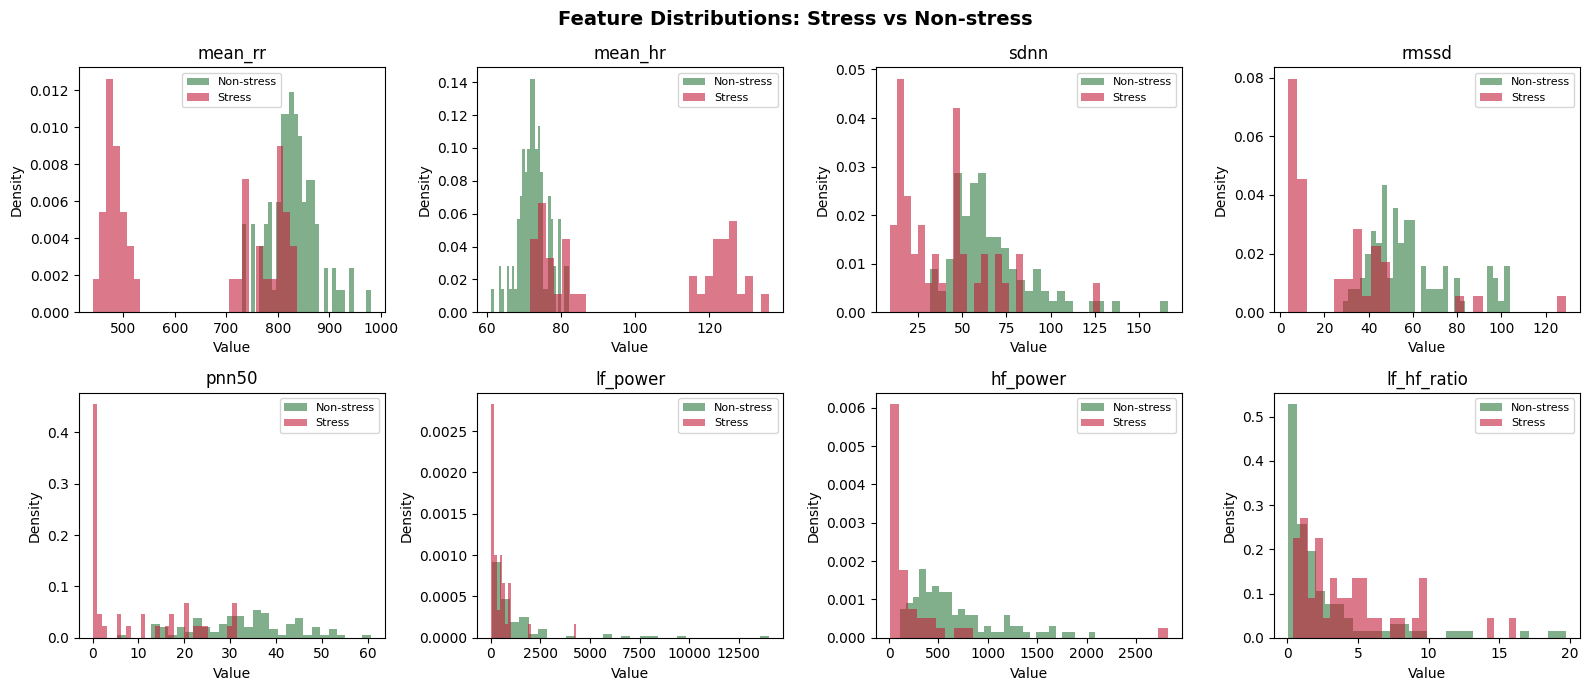

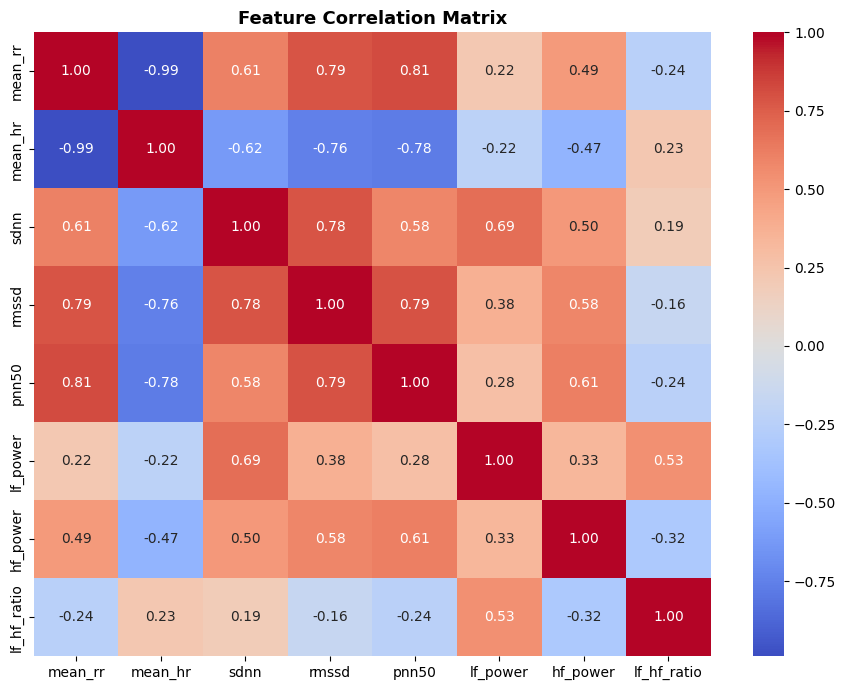

In [22]:
FEATURE_COLS = ['mean_rr', 'mean_hr', 'sdnn', 'rmssd', 'pnn50',
                'lf_power', 'hf_power', 'lf_hf_ratio']

print("=== Descriptive statistics by class ===")
display(df.groupby('label')[FEATURE_COLS].mean().rename(index={0:'Non-stress', 1:'Stress'}).round(3))

# Feature distributions
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
axes = axes.flatten()
for i, feat in enumerate(FEATURE_COLS):
    for cls, color, lbl in [(0, '#2d7a3e', 'Non-stress'), (1, '#c41e3a', 'Stress')]:
        axes[i].hist(df[df['label'] == cls][feat], bins=30, alpha=0.6,
                     color=color, label=lbl, density=True)
    axes[i].set_title(feat)
    axes[i].legend(fontsize=8)
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Density')
plt.suptitle('Feature Distributions: Stress vs Non-stress', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Correlation matrix
fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(df[FEATURE_COLS].corr(), annot=True, fmt='.2f', cmap='coolwarm',
            center=0, ax=ax)
ax.set_title('Feature Correlation Matrix', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### 300 Sec

In [23]:
# FEATURE_COLS = ['mean_rr', 'mean_hr', 'sdnn', 'rmssd', 'pnn50',
#                 'lf_power', 'hf_power', 'lf_hf_ratio']

# print("=== Descriptive statistics by class ===")
# display(df_300.groupby('label')[FEATURE_COLS].mean().rename(index={0:'Non-stress', 1:'Stress'}).round(3))

# # Feature distributions
# fig, axes = plt.subplots(2, 4, figsize=(16, 7))
# axes = axes.flatten()
# for i, feat in enumerate(FEATURE_COLS):
#     for cls, color, lbl in [(0, '#2d7a3e', 'Non-stress'), (1, '#c41e3a', 'Stress')]:
#         axes[i].hist(df_300[df_300['label'] == cls][feat], bins=30, alpha=0.6,
#                      color=color, label=lbl, density=True)
#     axes[i].set_title(feat)
#     axes[i].legend(fontsize=8)
#     axes[i].set_xlabel('Value')
#     axes[i].set_ylabel('Density')
# plt.suptitle('Feature Distributions: Stress vs Non-stress', fontsize=14, fontweight='bold')
# plt.tight_layout()
# plt.show()

# # Correlation matrix
# fig, ax = plt.subplots(figsize=(9, 7))
# sns.heatmap(df_300[FEATURE_COLS].corr(), annot=True, fmt='.2f', cmap='coolwarm',
#             center=0, ax=ax)
# ax.set_title('Feature Correlation Matrix', fontsize=13, fontweight='bold')
# plt.tight_layout()
# plt.show()

## 5. Leave-One-Subject-Out (LOSO) Cross-Validation

Each subject is held out once as the test set; the remaining subjects train the model.
This is the standard evaluation protocol for WESAD — it tests generalisation to unseen individuals.

In [24]:
def loso_evaluate(df, model, feature_cols):
    """
    Run Leave-One-Subject-Out CV and return per-fold and aggregate metrics.
    """
    subjects = sorted(df['subject_id'].unique())
    results  = []

    all_y_true, all_y_pred = [], []

    for test_subj in subjects:
        train_df = df[df['subject_id'] != test_subj]
        test_df  = df[df['subject_id'] == test_subj]

        X_train, y_train = train_df[feature_cols].values, train_df['label'].values
        X_test,  y_test  = test_df[feature_cols].values,  test_df['label'].values

        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        all_y_true.extend(y_test)
        all_y_pred.extend(y_pred)

        results.append({
            'subject':   test_subj,
            'accuracy':  accuracy_score(y_test, y_pred),
            'f1':        f1_score(y_test, y_pred, zero_division=0),
            'precision': precision_score(y_test, y_pred, zero_division=0),
            'recall':    recall_score(y_test, y_pred, zero_division=0),
            'n_test':    len(y_test),
        })

    results_df = pd.DataFrame(results).set_index('subject')
    overall = {
        'accuracy':  accuracy_score(all_y_true, all_y_pred),
        'f1':        f1_score(all_y_true, all_y_pred, zero_division=0),
        'precision': precision_score(all_y_true, all_y_pred, zero_division=0),
        'recall':    recall_score(all_y_true, all_y_pred, zero_division=0),
    }
    return results_df, overall, all_y_true, all_y_pred


print("LOSO evaluation function ready.")

LOSO evaluation function ready.


## 6. Model Definitions

Each model is wrapped in a `StandardScaler → Classifier` sklearn Pipeline so features
are always scaled on the training fold only (no data leakage).

In [25]:
models = {
    'SVM (RBF)': SklearnPipeline([
        ('scaler', StandardScaler()),
        ('clf',    SVC(kernel='rbf', C=1.0, gamma='scale', class_weight='balanced'))
    ]),
    'Random Forest': SklearnPipeline([
        ('scaler', StandardScaler()),
        ('clf',    RandomForestClassifier(n_estimators=200, class_weight='balanced',
                                          random_state=42, n_jobs=-1))
    ]),
    'LDA': SklearnPipeline([
        ('scaler', StandardScaler()),
        ('clf',    LinearDiscriminantAnalysis())
    ]),
    'KNN (k=5)': SklearnPipeline([
        ('scaler', StandardScaler()),
        ('clf',    KNeighborsClassifier(n_neighbors=5))
    ]),
    'Gradient Boosting': SklearnPipeline([
        ('scaler', StandardScaler()),
        ('clf',    GradientBoostingClassifier(n_estimators=200, learning_rate=0.05,
                                              max_depth=4, random_state=42))
    ]),
}

print(f"Models defined: {list(models.keys())}")

Models defined: ['SVM (RBF)', 'Random Forest', 'LDA', 'KNN (k=5)', 'Gradient Boosting']


## 7. Train & Evaluate All Models

### 30 Sec

In [26]:
all_results   = {}   # per-subject results for each model
all_overall   = {}   # aggregate metrics for each model
all_preds     = {}   # (y_true, y_pred) for confusion matrices

for model_name, model in models.items():
    print(f"\nRunning LOSO for: {model_name} ...")
    results_df, overall, y_true, y_pred = loso_evaluate(df, model, FEATURE_COLS)
    all_results[model_name] = results_df
    all_overall[model_name] = overall
    all_preds[model_name]   = (y_true, y_pred)
    print(f"  Overall Accuracy: {overall['accuracy']:.3f}  |  F1: {overall['f1']:.3f}  |  "
          f"Precision: {overall['precision']:.3f}  |  Recall: {overall['recall']:.3f}")


Running LOSO for: SVM (RBF) ...
  Overall Accuracy: 0.573  |  F1: 0.000  |  Precision: 0.000  |  Recall: 0.000

Running LOSO for: Random Forest ...
  Overall Accuracy: 0.713  |  F1: 0.518  |  Precision: 0.512  |  Recall: 0.524

Running LOSO for: LDA ...
  Overall Accuracy: 0.706  |  F1: 0.512  |  Precision: 0.500  |  Recall: 0.524

Running LOSO for: KNN (k=5) ...
  Overall Accuracy: 0.790  |  F1: 0.595  |  Precision: 0.688  |  Recall: 0.524

Running LOSO for: Gradient Boosting ...
  Overall Accuracy: 0.741  |  F1: 0.543  |  Precision: 0.564  |  Recall: 0.524


In [27]:
# all_results_300 = {}   # per-subject results for each model
# all_overall_300  = {}   # aggregate metrics for each model
# all_preds_300     = {}   # (y_true, y_pred) for confusion matrices

# for model_name, model in models.items():
#     print(f"\nRunning LOSO for: {model_name} ...")
#     results_df_300, overall_300, y_true_300, y_pred_300 = loso_evaluate(df_300, model, FEATURE_COLS)
#     all_results_300[model_name] = results_df_300
#     all_overall_300[model_name] = overall_300
#     all_preds_300[model_name]   = (y_true_300, y_pred_300)
#     print(f"  Overall Accuracy: {overall_300['accuracy']:.3f}  |  F1: {overall_300['f1']:.3f}  |  "
#           f"Precision: {overal_300l['precision']:.3f}  |  Recall: {overall_300['recall']:.3f}")

## 8. Results Summary

### 30 Sec

In [28]:
def color_metric(val):
    if val >= 0.80: return 'background-color: #2d7a3e; color: white; font-weight: bold'
    elif val >= 0.60: return 'background-color: #f4a460; color: black; font-weight: bold'
    else: return 'background-color: #c41e3a; color: white; font-weight: bold'

# --- Overall comparison table ---
summary = pd.DataFrame(all_overall).T
summary.index.name = 'Model'
summary = summary.sort_values('f1', ascending=False)

print("=== Overall LOSO Results (all subjects pooled) ===")
styled = (summary.style
          .map(color_metric)
          .format('{:.4f}')
          .set_caption('Model Comparison — LOSO Cross-Validation')
          .set_table_styles([{
              'selector': 'caption',
              'props': [('font-size','15px'),('font-weight','bold'),
                        ('text-align','left'),('padding-bottom','6px')]
          }]))
display(styled)

=== Overall LOSO Results (all subjects pooled) ===


,accuracy,f1,precision,recall
Model,,,,
KNN (k=5),0.7902,0.5946,0.6875,0.5238
Gradient Boosting,0.7413,0.5432,0.5641,0.5238
Random Forest,0.7133,0.5176,0.5116,0.5238
LDA,0.7063,0.5116,0.5000,0.5238
SVM (RBF),0.5734,0.0000,0.0000,0.0000


### 300 Sec

In [29]:
# def color_metric(val):
#     if val >= 0.80: return 'background-color: #2d7a3e; color: white; font-weight: bold'
#     elif val >= 0.60: return 'background-color: #f4a460; color: black; font-weight: bold'
#     else: return 'background-color: #c41e3a; color: white; font-weight: bold'

# # --- Overall comparison table ---
# summary = pd.DataFrame(all_overall).T
# summary.index.name = 'Model'
# summary = summary.sort_values('f1', ascending=False)

# print("=== Overall LOSO Results (all subjects pooled) ===")
# styled = (summary.style
#           .map(color_metric)
#           .format('{:.4f}')
#           .set_caption('Model Comparison — LOSO Cross-Validation')
#           .set_table_styles([{
#               'selector': 'caption',
#               'props': [('font-size','15px'),('font-weight','bold'),
#                         ('text-align','left'),('padding-bottom','6px')]
#           }]))
# display(styled)

In [30]:
# --- Per-subject breakdown for each model ---
for model_name, results_df in all_results.items():
    print(f"\n{'─'*55}")
    print(f"  Per-subject results: {model_name}")
    print(f"{'─'*55}")
    styled_sub = (results_df[['accuracy','f1','precision','recall']].style
                  .map(color_metric, subset=['accuracy','f1','precision','recall'])
                  .format('{:.4f}', subset=['accuracy','f1','precision','recall'])
                  .set_caption(f"{model_name} — per subject"))
    display(styled_sub)


───────────────────────────────────────────────────────
  Per-subject results: SVM (RBF)
───────────────────────────────────────────────────────


,accuracy,f1,precision,recall
subject,,,,
0,0.4384,0.0000,0.0000,0.0000
1,0.7143,0.0000,0.0000,0.0000



───────────────────────────────────────────────────────
  Per-subject results: Random Forest
───────────────────────────────────────────────────────


,accuracy,f1,precision,recall
subject,,,,
0,0.7123,0.6769,0.5116,1.0000
1,0.7143,0.0000,0.0000,0.0000



───────────────────────────────────────────────────────
  Per-subject results: LDA
───────────────────────────────────────────────────────


,accuracy,f1,precision,recall
subject,,,,
0,0.6986,0.6667,0.5000,1.0000
1,0.7143,0.0000,0.0000,0.0000



───────────────────────────────────────────────────────
  Per-subject results: KNN (k=5)
───────────────────────────────────────────────────────


,accuracy,f1,precision,recall
subject,,,,
0,0.8630,0.8148,0.6875,1.0000
1,0.7143,0.0000,0.0000,0.0000



───────────────────────────────────────────────────────
  Per-subject results: Gradient Boosting
───────────────────────────────────────────────────────


,accuracy,f1,precision,recall
subject,,,,
0,0.7671,0.7213,0.5641,1.0000
1,0.7143,0.0000,0.0000,0.0000


## 9. Confusion Matrices

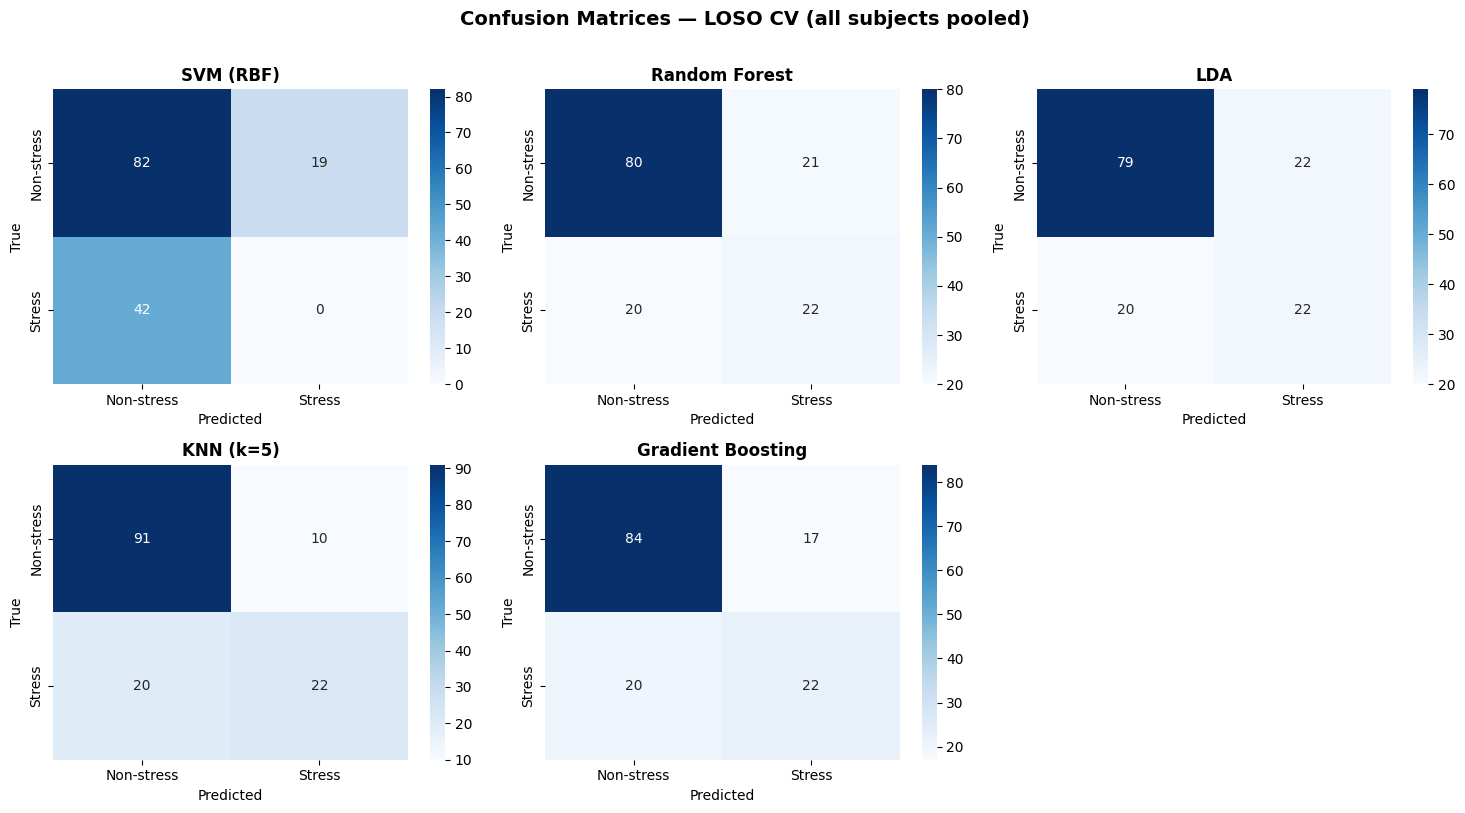

In [31]:
n_models = len(models)
ncols    = 3
nrows    = (n_models + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 5, nrows * 4))
axes = axes.flatten()

for idx, (model_name, (y_true, y_pred)) in enumerate(all_preds.items()):
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx],
                xticklabels=['Non-stress', 'Stress'],
                yticklabels=['Non-stress', 'Stress'])
    axes[idx].set_title(model_name, fontweight='bold')
    axes[idx].set_xlabel('Predicted')
    axes[idx].set_ylabel('True')

# Hide unused subplots
for idx in range(len(models), len(axes)):
    axes[idx].set_visible(False)

plt.suptitle('Confusion Matrices — LOSO CV (all subjects pooled)',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## 10. Feature Importance (Random Forest)

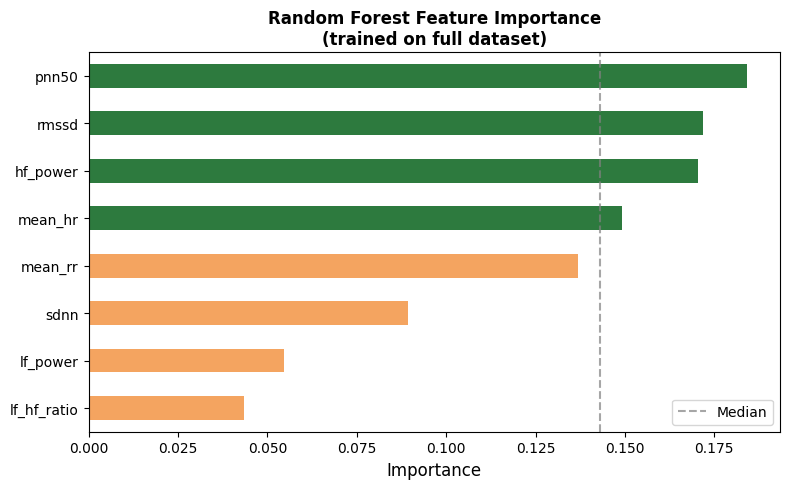

Feature importances:


,importance
pnn50,0.1841
rmssd,0.1719
hf_power,0.1705
mean_hr,0.1490
mean_rr,0.1368
sdnn,0.0893
lf_power,0.0547
lf_hf_ratio,0.0436


In [32]:
# Retrain Random Forest on ALL data to get stable feature importances
rf_full = RandomForestClassifier(n_estimators=500, class_weight='balanced',
                                  random_state=42, n_jobs=-1)
scaler_full = StandardScaler()
X_all = scaler_full.fit_transform(df[FEATURE_COLS].values)
y_all = df['label'].values
rf_full.fit(X_all, y_all)

importances = pd.Series(rf_full.feature_importances_, index=FEATURE_COLS).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 5))
colors = ['#2d7a3e' if v >= importances.median() else '#f4a460' for v in importances]
importances.plot(kind='barh', ax=ax, color=colors)
ax.set_xlabel('Importance', fontsize=12)
ax.set_title('Random Forest Feature Importance\n(trained on full dataset)', fontweight='bold')
ax.axvline(importances.median(), color='gray', linestyle='--', alpha=0.7, label='Median')
ax.legend()
plt.tight_layout()
plt.show()

print("Feature importances:")
display(importances.sort_values(ascending=False).to_frame('importance').round(4))

## 11. Best Model — Detailed Report

In [33]:
best_model_name = summary.index[0]   # highest F1
y_true_best, y_pred_best = all_preds[best_model_name]

print(f"Best model: {best_model_name}\n")
print(classification_report(
    y_true_best, y_pred_best,
    target_names=['Non-stress', 'Stress']
))

Best model: KNN (k=5)

              precision    recall  f1-score   support

  Non-stress       0.82      0.90      0.86       101
      Stress       0.69      0.52      0.59        42

    accuracy                           0.79       143
   macro avg       0.75      0.71      0.73       143
weighted avg       0.78      0.79      0.78       143



## 12. 300-Second Window Analysis

We repeat the entire LOSO pipeline on `df_300` (300-second windows, i.e. 5-minute chunks) 
and compare it against the 30-second results. Longer windows:

- Contain more RR intervals -> more stable HRV estimates (especially LF/HF PSD)
- Yield fewer samples per subject (~10x fewer windows)
- Are more affected by label transitions / non-stationarity

In [34]:
print(f"df  (30s)  shape: {df.shape}")
print(f"df_300 shape: {df_300.shape}\n")

print("Class distribution - 30s windows:")
display(df['label'].value_counts().rename({0:'Non-stress', 1:'Stress'}).to_frame('count'))

print("\nClass distribution - 300s windows:")
display(df_300['label'].value_counts().rename({0:'Non-stress', 1:'Stress'}).to_frame('count'))

df  (30s)  shape: (143, 10)
df_300 shape: (15, 10)

Class distribution - 30s windows:


,count
label,
Non-stress,101
Stress,42



Class distribution - 300s windows:


,count
label,
Non-stress,10
Stress,5


### 12.1 Run LOSO CV on the 300-second dataset

In [35]:
all_results_300 = {}
all_overall_300 = {}
all_preds_300   = {}

for model_name, model in models.items():
    print(f"\nRunning LOSO (300s) for: {model_name} ...")
    results_df, overall, y_true, y_pred = loso_evaluate(df_300, model, FEATURE_COLS)
    all_results_300[model_name] = results_df
    all_overall_300[model_name] = overall
    all_preds_300[model_name]   = (y_true, y_pred)
    print(f"  Overall Accuracy: {overall['accuracy']:.3f}  |  F1: {overall['f1']:.3f}  |  "
          f"Precision: {overall['precision']:.3f}  |  Recall: {overall['recall']:.3f}")


Running LOSO (300s) for: SVM (RBF) ...
  Overall Accuracy: 0.533  |  F1: 0.000  |  Precision: 0.000  |  Recall: 0.000

Running LOSO (300s) for: Random Forest ...
  Overall Accuracy: 0.667  |  F1: 0.545  |  Precision: 0.500  |  Recall: 0.600

Running LOSO (300s) for: LDA ...
  Overall Accuracy: 0.533  |  F1: 0.000  |  Precision: 0.000  |  Recall: 0.000

Running LOSO (300s) for: KNN (k=5) ...
  Overall Accuracy: 0.667  |  F1: 0.000  |  Precision: 0.000  |  Recall: 0.000

Running LOSO (300s) for: Gradient Boosting ...
  Overall Accuracy: 0.667  |  F1: 0.545  |  Precision: 0.500  |  Recall: 0.600


### 12.2 300-Second Results Summary

In [36]:
summary_300 = pd.DataFrame(all_overall_300).T
summary_300.index.name = 'Model'
summary_300 = summary_300.sort_values('f1', ascending=False)

print("=== Overall LOSO Results on 300-second windows ===")
styled_300 = (summary_300.style
             .map(color_metric)
             .format('{:.4f}')
             .set_caption('Model Comparison - LOSO CV (300s windows)')
             .set_table_styles([{
                 'selector': 'caption',
                 'props': [('font-size','15px'),('font-weight','bold'),
                           ('text-align','left'),('padding-bottom','6px')]
             }]))
display(styled_300)

=== Overall LOSO Results on 300-second windows ===


,accuracy,f1,precision,recall
Model,,,,
Random Forest,0.6667,0.5455,0.5000,0.6000
Gradient Boosting,0.6667,0.5455,0.5000,0.6000
SVM (RBF),0.5333,0.0000,0.0000,0.0000
LDA,0.5333,0.0000,0.0000,0.0000
KNN (k=5),0.6667,0.0000,0.0000,0.0000


### 12.3 Side-by-Side: 30 s vs 300 s

In [37]:
summary_30s_view       = summary.copy()
summary_30s_view['window'] = '30 s'

summary_300_view       = summary_300.copy()
summary_300_view['window'] = '300 s'

combined = pd.concat([summary_30s_view, summary_300_view]).reset_index()
combined = combined[['window', 'Model', 'accuracy', 'f1', 'precision', 'recall']]

print("=== 30 s vs 300 s - Overall LOSO metrics ===")
styled_combined = (combined.style
                  .map(color_metric, subset=['accuracy','f1','precision','recall'])
                  .format('{:.4f}', subset=['accuracy','f1','precision','recall'])
                  .set_caption('Side-by-side: 30 s vs 300 s windows')
                  .set_table_styles([{
                      'selector': 'caption',
                      'props': [('font-size','15px'),('font-weight','bold'),
                                ('text-align','left'),('padding-bottom','6px')]
                  }]))
display(styled_combined)

=== 30 s vs 300 s - Overall LOSO metrics ===


,window,Model,accuracy,f1,precision,recall
0,30 s,KNN (k=5),0.7902,0.5946,0.6875,0.5238
1,30 s,Gradient Boosting,0.7413,0.5432,0.5641,0.5238
2,30 s,Random Forest,0.7133,0.5176,0.5116,0.5238
3,30 s,LDA,0.7063,0.5116,0.5000,0.5238
4,30 s,SVM (RBF),0.5734,0.0000,0.0000,0.0000
5,300 s,Random Forest,0.6667,0.5455,0.5000,0.6000
6,300 s,Gradient Boosting,0.6667,0.5455,0.5000,0.6000
7,300 s,SVM (RBF),0.5333,0.0000,0.0000,0.0000
8,300 s,LDA,0.5333,0.0000,0.0000,0.0000
9,300 s,KNN (k=5),0.6667,0.0000,0.0000,0.0000


In [38]:
delta = (summary_300[['accuracy','f1','precision','recall']]
         - summary[['accuracy','f1','precision','recall']])
delta.index.name = 'Model'

print("=== Delta (300 s - 30 s)  ·  positive = 300 s is better ===")
styled_delta = (delta.style
               .map(color_metric)
               .format('{:+.4f}')
               .set_caption('Metric change when switching to 300 s windows')
               .set_table_styles([{
                   'selector': 'caption',
                   'props': [('font-size','15px'),('font-weight','bold'),
                             ('text-align','left'),('padding-bottom','6px')]
               }]))
display(styled_delta)

=== Delta (300 s - 30 s)  ·  positive = 300 s is better ===


,accuracy,f1,precision,recall
Model,,,,
Gradient Boosting,-0.0746,+0.0022,-0.0641,+0.0762
KNN (k=5),-0.1235,-0.5946,-0.6875,-0.5238
LDA,-0.1730,-0.5116,-0.5000,-0.5238
Random Forest,-0.0466,+0.0278,-0.0116,+0.0762
SVM (RBF),-0.0401,+0.0000,+0.0000,+0.0000


### 12.4 Bar Plot - F1 per Model per Window

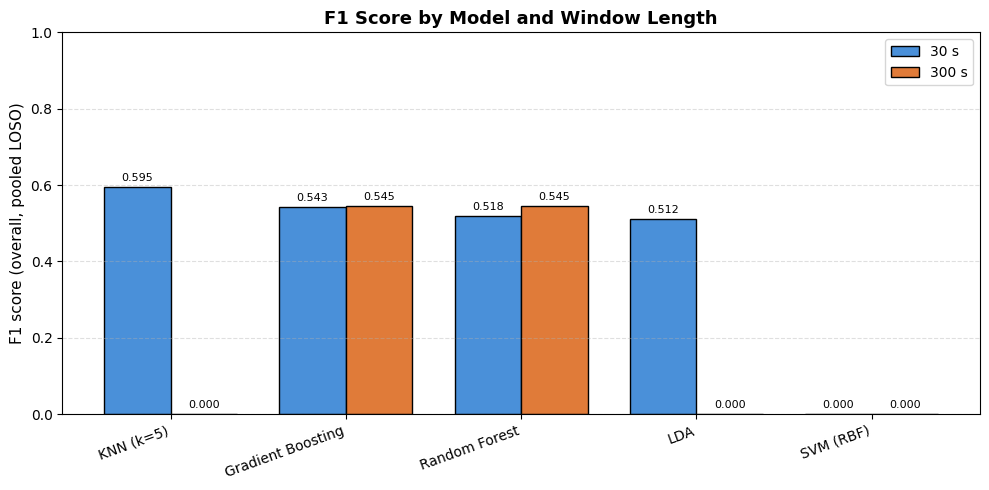

In [39]:
fig, ax = plt.subplots(figsize=(10, 5))

x = np.arange(len(summary.index))
width = 0.38

f1_30  = summary['f1'].reindex(summary.index).values
f1_300 = summary_300['f1'].reindex(summary.index).values

bars1 = ax.bar(x - width/2, f1_30,  width, label='30 s',  color='#4a90d9', edgecolor='black')
bars2 = ax.bar(x + width/2, f1_300, width, label='300 s', color='#e07b39', edgecolor='black')

for b in list(bars1) + list(bars2):
    ax.annotate(f'{b.get_height():.3f}',
                xy=(b.get_x() + b.get_width() / 2, b.get_height()),
                xytext=(0, 3), textcoords='offset points',
                ha='center', va='bottom', fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels(summary.index, rotation=20, ha='right')
ax.set_ylim(0, 1.0)
ax.set_ylabel('F1 score (overall, pooled LOSO)', fontsize=11)
ax.set_title('F1 Score by Model and Window Length', fontsize=13, fontweight='bold')
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

### 12.5 Confusion Matrices - 300 s windows

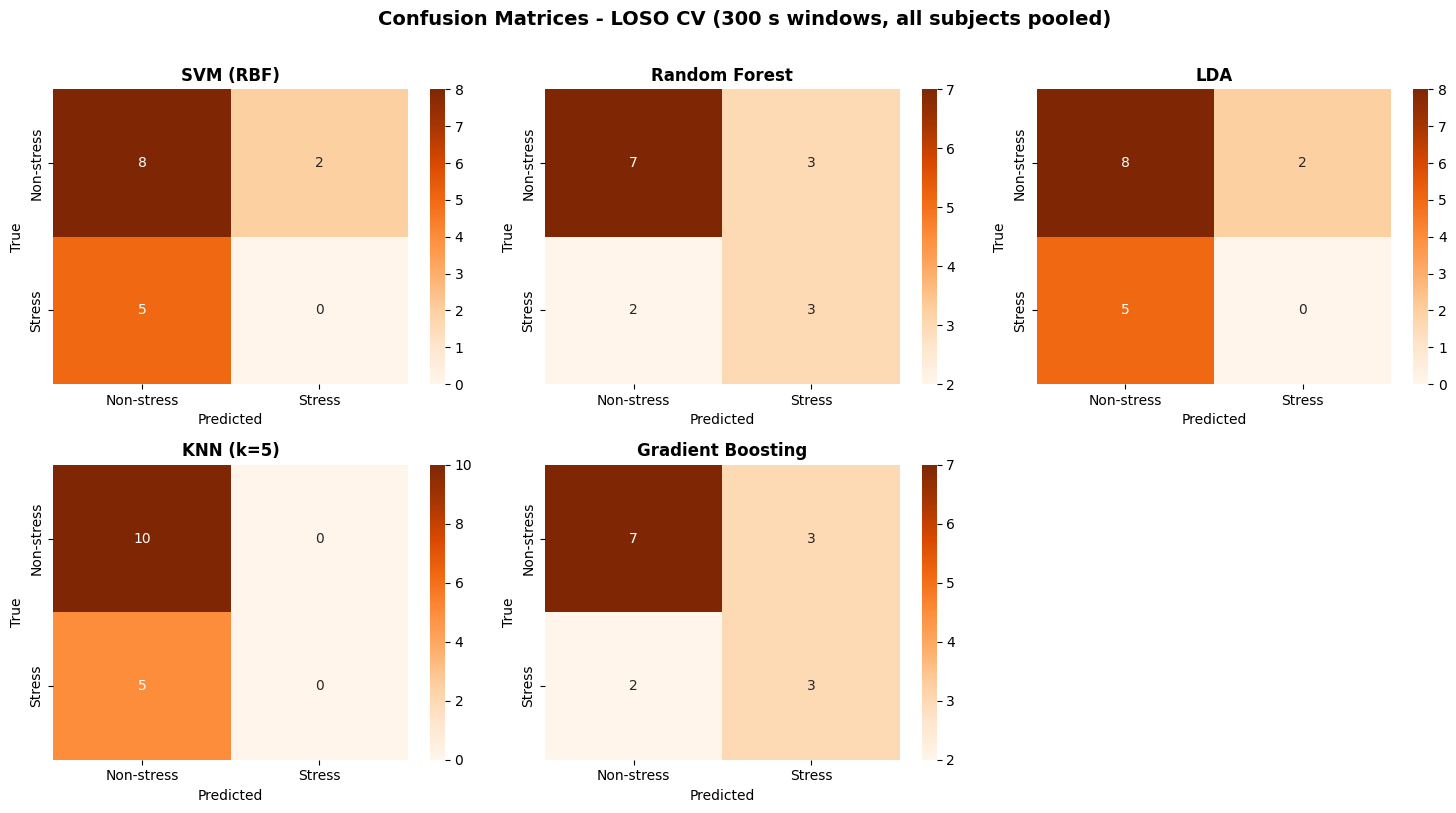

In [40]:
n_models_300 = len(all_preds_300)
ncols_300    = 3
nrows_300    = (n_models_300 + ncols_300 - 1) // ncols_300
fig, axes = plt.subplots(nrows_300, ncols_300, figsize=(ncols_300 * 5, nrows_300 * 4))
axes = axes.flatten()

for idx, (model_name, (y_true, y_pred)) in enumerate(all_preds_300.items()):
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges', ax=axes[idx],
                xticklabels=['Non-stress', 'Stress'],
                yticklabels=['Non-stress', 'Stress'])
    axes[idx].set_title(model_name, fontweight='bold')
    axes[idx].set_xlabel('Predicted')
    axes[idx].set_ylabel('True')

for idx in range(len(all_preds_300), len(axes)):
    axes[idx].set_visible(False)

plt.suptitle('Confusion Matrices - LOSO CV (300 s windows, all subjects pooled)',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

### 12.6 Feature Importance (Random Forest) on 300 s

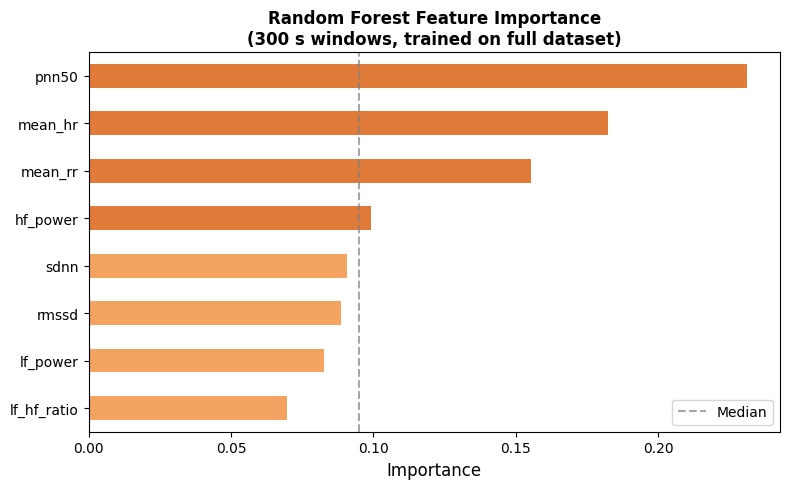

Feature importances (300 s):


,importance
pnn50,0.2313
mean_hr,0.1824
mean_rr,0.1553
hf_power,0.0991
sdnn,0.0908
rmssd,0.0887
lf_power,0.0826
lf_hf_ratio,0.0698


In [41]:
rf_full_300 = RandomForestClassifier(n_estimators=500, class_weight='balanced',
                                     random_state=42, n_jobs=-1)
scaler_full_300 = StandardScaler()
X_all_300 = scaler_full_300.fit_transform(df_300[FEATURE_COLS].values)
y_all_300 = df_300['label'].values
rf_full_300.fit(X_all_300, y_all_300)

importances_300 = pd.Series(rf_full_300.feature_importances_,
                             index=FEATURE_COLS).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 5))
colors_300 = ['#e07b39' if v >= importances_300.median() else '#f4a460'
              for v in importances_300]
importances_300.plot(kind='barh', ax=ax, color=colors_300)
ax.set_xlabel('Importance', fontsize=12)
ax.set_title('Random Forest Feature Importance\n(300 s windows, trained on full dataset)',
             fontweight='bold')
ax.axvline(importances_300.median(), color='gray', linestyle='--', alpha=0.7, label='Median')
ax.legend()
plt.tight_layout()
plt.show()

print("Feature importances (300 s):")
display(importances_300.sort_values(ascending=False).to_frame('importance').round(4))

### 12.7 Feature-importance comparison: 30 s vs 300 s

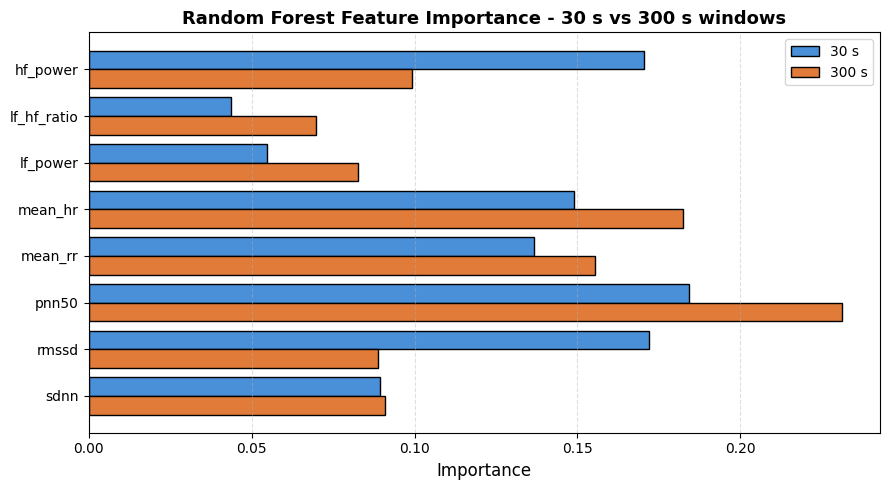

In [42]:
imp_compare = pd.DataFrame({
    '30 s':  importances.sort_values(ascending=False),
    '300 s': importances_300.sort_values(ascending=False),
})

fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(len(imp_compare))
width = 0.4

ax.barh(x - width/2, imp_compare['30 s'].values,  width,
        label='30 s',  color='#4a90d9', edgecolor='black')
ax.barh(x + width/2, imp_compare['300 s'].values, width,
        label='300 s', color='#e07b39', edgecolor='black')

ax.set_yticks(x)
ax.set_yticklabels(imp_compare.index)
ax.invert_yaxis()
ax.set_xlabel('Importance', fontsize=12)
ax.set_title('Random Forest Feature Importance - 30 s vs 300 s windows',
             fontsize=13, fontweight='bold')
ax.legend()
ax.grid(axis='x', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

### 12.8 Best Model on 300 s - Detailed Report

In [43]:
best_model_name_300 = summary_300.index[0]   # highest F1 on 300 s data
y_true_best_300, y_pred_best_300 = all_preds_300[best_model_name_300]

print(f"Best model on 300 s: {best_model_name_300}\n")
print(classification_report(
    y_true_best_300, y_pred_best_300,
    target_names=['Non-stress', 'Stress']
))

Best model on 300 s: Random Forest

              precision    recall  f1-score   support

  Non-stress       0.78      0.70      0.74        10
      Stress       0.50      0.60      0.55         5

    accuracy                           0.67        15
   macro avg       0.64      0.65      0.64        15
weighted avg       0.69      0.67      0.67        15



### 12.9 Take-aways

- **30 s windows** give more samples per subject but each sample carries noisier frequency-domain estimates (LF/HF), so PSD-based features are less reliable.
- **300 s windows** give far fewer samples (typically 10x fewer) but each HRV estimate is averaged over many more beats - the Welch PSD becomes much smoother and the LF/HF ratio is a more trustworthy proxy of sympathovagal balance.
- Watch the **Delta table** (12.3) and the **bar plot** (12.4) to see which model actually benefits from longer windows. Models that lean on `lf_hf_ratio` / `lf_power` / `hf_power` (e.g. SVM, LDA) usually improve; tree-based models with `class_weight` tend to be more robust either way.
- Always weigh any accuracy/F1 gain against the **~10x reduction in sample size** - 300 s results have higher variance per LOSO fold.